# Cost-Sensitive Credit Risk Modeling and Business Metric Alignment

**Dataset:** Default of Credit Card Clients (UCI Machine Learning Repository)  
**Task:** Binary classification — predict next-month default  
**Focus:** Minimize financial cost of False Negatives (missed defaulters) rather than pure accuracy or F1

---

### Project Overview

This notebook implements an end-to-end, production-oriented pipeline for credit-card default prediction.  
Instead of optimizing generic classification metrics, the entire workflow is aligned with a **business cost function**:

- **False Negative (FN)** cost = 3  
- **False Positive (FP)** cost = 1  

The pipeline covers four critical stages:

1. **Automated Hyperparameter Tuning** — Optuna search for LightGBM and CatBoost  
2. **Probability Calibration** — Isotonic regression via `CalibratedClassifierCV`  
3. **Threshold Optimization** — Direct minimization of the financial cost function  
4. **Robust Evaluation** — Calibration curves, business-cost curves, SHAP explanations, and model comparison (Blending, Stacking, AutoGluon)

A production inference bundle and a Gradio + Cloudflare demo are also provided.

## 1. Environment Setup

In [2]:
# Install required packages (Colab-friendly)


!pip install feature-engine --no-deps
!pip install optuna
!pip install pytimetk
!pip install skrub gradio optuna-integration
!pip install -U ydata-profiling
# Optional: AutoGluon (comment out if you want a lighter runtime)
!pip install -U uv
!uv pip install --system autogluon

print("Packages ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 94.9 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Resolved 240 packages in 2.64s
Prepared 72 packages in 3.87s
Uninstalled 13 packages in 633ms
Installed 72 packages in 203ms
 + adagio==0.2.6
 + aiohttp-cors==0.8.1
 + apswutils==0.1.2
 + autogluon==1.6.3
 + autogluon-common==1.6.3
 + autogluon-core==1.6.3
 + autogluon-features==1.6.3
 + autogluon-multimodal==1.6.3
 + autogluon-tabular==1.6.3
 + autogluon-timeseries==1.6.3
 + boto3==1.43.108
 + botocore==1.43.108
 + catboost==1.2.10
 + chronos-forecasting==2.3.2
 + colorama==0.4.6
 + colorful==0.5.8
 + coreforecast==0.0.16
 + distlib==0.4.3
 + einx==0.4.3
 + evaluate==0.4.6
 - fastai==2.8.12
 + fastai==2.8.7
 - fastcore==2.2.28
 + fastcore==1.14.5
 + fastlite==0.2.4
 - fasttransform==0.0.5
 + fasttransform==0.0.2
 + fugue==0.9.7
 + gluonts==0.17.0
 - hyperopt==0.3.0
 + hyperopt==0.2.7
 + jmespath==1.1.0
 - jsonschema==4.26.0
 + jsonschema==4.23.0
 + lightning==2.6.6


In [9]:
import os
import warnings
import logging
import re
import time
import subprocess
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from scipy.optimize import minimize, minimize_scalar

import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
from optuna.integration import LightGBMPruningCallback, CatBoostPruningCallback

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    f1_score, balanced_accuracy_score, accuracy_score,
    confusion_matrix, classification_report, make_scorer
)
from sklearn.feature_selection import SelectKBest, SelectPercentile, f_classif
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

import joblib
import shap
from pandas_transformers import (
    categorizar_todo_pandas,
    add_time_features_pandas,
    Flagnan3,
    Flagout2,
    RareLabelPandas,
    TargetEncoderFastPandas2,
    BiniPandas2,
    PercentileRankerPandas2,
    ZeroInflatedTransformerPandas2,
)
from dashboards2 import (
    classify_variables,
    fast_eda_report,
    compute_feature_diagnostics,
    audit_fe_information_gain,
    plot_classification_correlations_plotly
)
from loaders import skim, clean_dataframe
from domain import (
    engineer_credit_features
)

# Silence verbose libraries
os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["LIGHTGBM_SILENT"] = "true"
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.getLogger("lightgbm").setLevel(logging.ERROR)
logging.getLogger("catboost").setLevel(logging.ERROR)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports complete.")

Imports complete.


## 2. Dataset Description & Business Context

### Source
Default of Credit Card Clients Dataset — [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients)

- **Instances:** 30,000 credit-card clients in Taiwan  
- **Collection period:** April 2005 – September 2005  
- **Target:** `default.payment.next.month` (1 = default, 0 = no default)  
- **Features:** 23 (demographics, credit limit, 6-month payment history, bill statements, repayment amounts)

### Important Considerations

| Topic | Guidance |
|-------|----------|
| **Data leakage** | If predicting October default, features from September (`PAY_0`, `BILL_AMT1`, `PAY_AMT1`) should be excluded for pure forecasting. Here we treat the task as **detection / risk scoring**, so they are retained. |
| **Class imbalance** | Defaults are the minority class → use cost-sensitive metrics, calibrated probabilities and threshold tuning. |
| **Duplicates** | Exact duplicates exist and should be removed. |

### Business Cost Definition

```
Total Cost = FN × 3 + FP × 1
```

A missed defaulter (FN) is three times more expensive than an unnecessary investigation (FP).  
All model selection, thresholding and final ranking are driven by this cost.

## 3. Load Data & Train/Test Split

In [14]:
# Download the dataset if not present
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
LOCAL_CSV = "UCI_Credit_Card.csv"

if not os.path.exists(LOCAL_CSV):
    # Fallback: try the common Kaggle/UCI CSV mirror
    try:
        df_raw = pd.read_excel(DATA_URL, header=1)
        df_raw.to_csv(LOCAL_CSV, index=False)
    except Exception:
        # Alternative public mirror (if Excel fails)
        df_raw = pd.read_csv(
            "https://raw.githubusercontent.com/jbrownlee/Datasets/master/default%20of%20credit%20card%20clients.csv",
            header=1
        )
        df_raw.to_csv(LOCAL_CSV, index=False)
else:
    df_raw = pd.read_csv(LOCAL_CSV)

target= "default.payment.next.month"
if target not in df_raw.columns:
    # Some mirrors use slightly different naming
    target = [c for c in df_raw.columns if "default" in c.lower()][0]

print(f"Shape: {df_raw.shape}")
print(f"Target distribution:\n{df_raw[target].value_counts(normalize=True).round(3)}")
df_raw.head()

Shape: (30000, 25)
Target distribution:
default.payment.next.month
0    0.779
1    0.221
Name: proportion, dtype: float64


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [15]:
# Remove exact duplicates and ID if present
df = df_raw.copy()
if "ID" in df.columns:
    df = df.drop(columns=["ID"])
n_before = len(df)
df = df.drop_duplicates()
print(f"Removed {n_before - len(df)} exact duplicates.")

y = df[target]
X = df.drop(columns=[target])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train_raw.shape} | Test: {X_test_raw.shape}")
print(f"Train positive rate: {y_train.mean():.3f} | Test positive rate: {y_test.mean():.3f}")

Removed 35 exact duplicates.
Train: (22473, 23) | Test: (7492, 23)
Train positive rate: 0.221 | Test positive rate: 0.221


## 4. Exploratory Data Analysis & Drift Check

In [6]:
def detect_drift(reference, current, numerical_threshold=0.05, categorical_threshold=0.05):
    """Detect distribution drift (KS for numeric, Chi-squared for categorical)."""
    results = {}
    common = set(reference.columns) & set(current.columns)
    for col in common:
        if pd.api.types.is_numeric_dtype(reference[col]):
            stat, p = stats.ks_2samp(reference[col].dropna(), current[col].dropna())
            results[col] = {"type": "numeric", "statistic": stat, "p_value": p,
                            "drift": p < numerical_threshold}
        else:
            ref_c = reference[col].value_counts()
            cur_c = current[col].value_counts()
            cats = sorted(set(ref_c.index) | set(cur_c.index))
            ref_a = ref_c.reindex(cats, fill_value=0)
            cur_a = cur_c.reindex(cats, fill_value=0)
            stat, p, _, _ = stats.chi2_contingency([ref_a, cur_a])
            results[col] = {"type": "categorical", "statistic": stat, "p_value": p,
                            "drift": p < categorical_threshold}
    return results


def drift_summary(reference, current):
    res = detect_drift(reference, current)
    df_d = pd.DataFrame(res).T
    drifted = df_d[df_d["drift"] == True]
    print(f"Total features: {len(df_d)} | Drifted: {len(drifted)}")
    if not drifted.empty:
        print("\nFeatures with drift:")
        for f in drifted.index:
            print(f"  - {f} (stat={drifted.loc[f,'statistic']:.4f}, p={drifted.loc[f,'p_value']:.4f})")
    return df_d


print("=== DRIFT SUMMARY (Train vs Test) ===")
drift_df = drift_summary(X_train_raw, X_test_raw)

=== DRIFT SUMMARY (Train vs Test) ===
Total features: 23 | Drifted: 0


⚡ FAST EDA DIAGNOSTIC REPORT
Shape   : 22,473 rows × 23 columns
Memory  : 4.62 MB

-------------------------------------------------------
VARIABLE CLASSIFICATION SUMMARY
-------------------------------------------------------
• Continuous : 14
• Discrete   : 9
• Categorical: 0 (Low-Card: 0, High-Card: 0)
• Date       : 0

QUALITY ALERTS:
  ⚠️ PAY_0: zero-inflated (49.3% zeros)
  ⚠️ PAY_0: high coefficient of variation (CV = 94.5)
  ⚠️ PAY_2: zero-inflated (52.6% zeros)
  ⚠️ PAY_2: high coefficient of variation (CV = 9.3)
  ⚠️ PAY_3: zero-inflated (52.8% zeros)
  ⚠️ PAY_3: high coefficient of variation (CV = 7.2)
  ⚠️ PAY_4: zero-inflated (55.0% zeros)
  ⚠️ PAY_4: high coefficient of variation (CV = 5.2)
  ⚠️ PAY_5: zero-inflated (56.6% zeros)
  ⚠️ PAY_5: high coefficient of variation (CV = 4.2)
  ... and 14 additional alerts.

-------------------------------------------------------
MISSING VALUES SUMMARY
-------------------------------------------------------
No missing values detecte

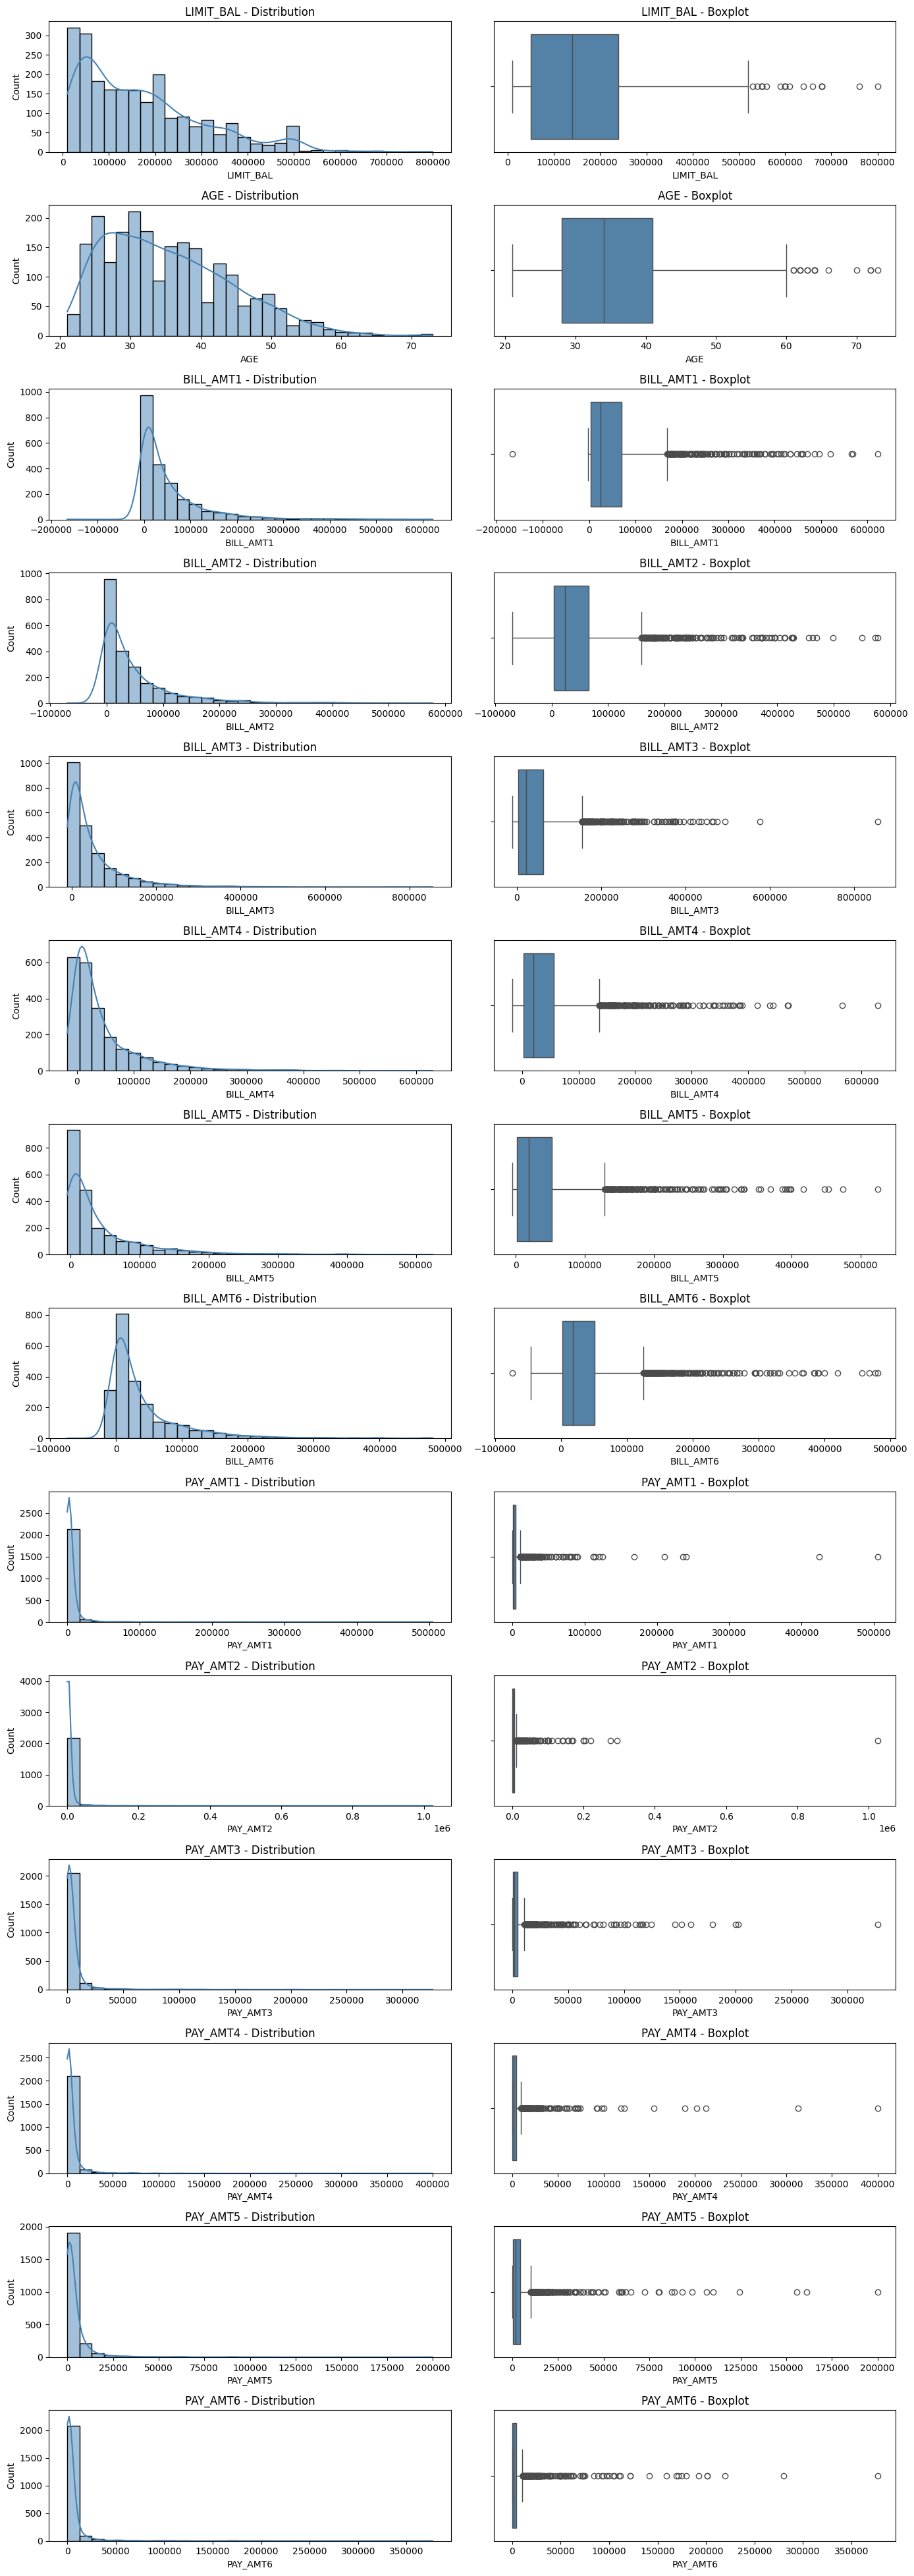

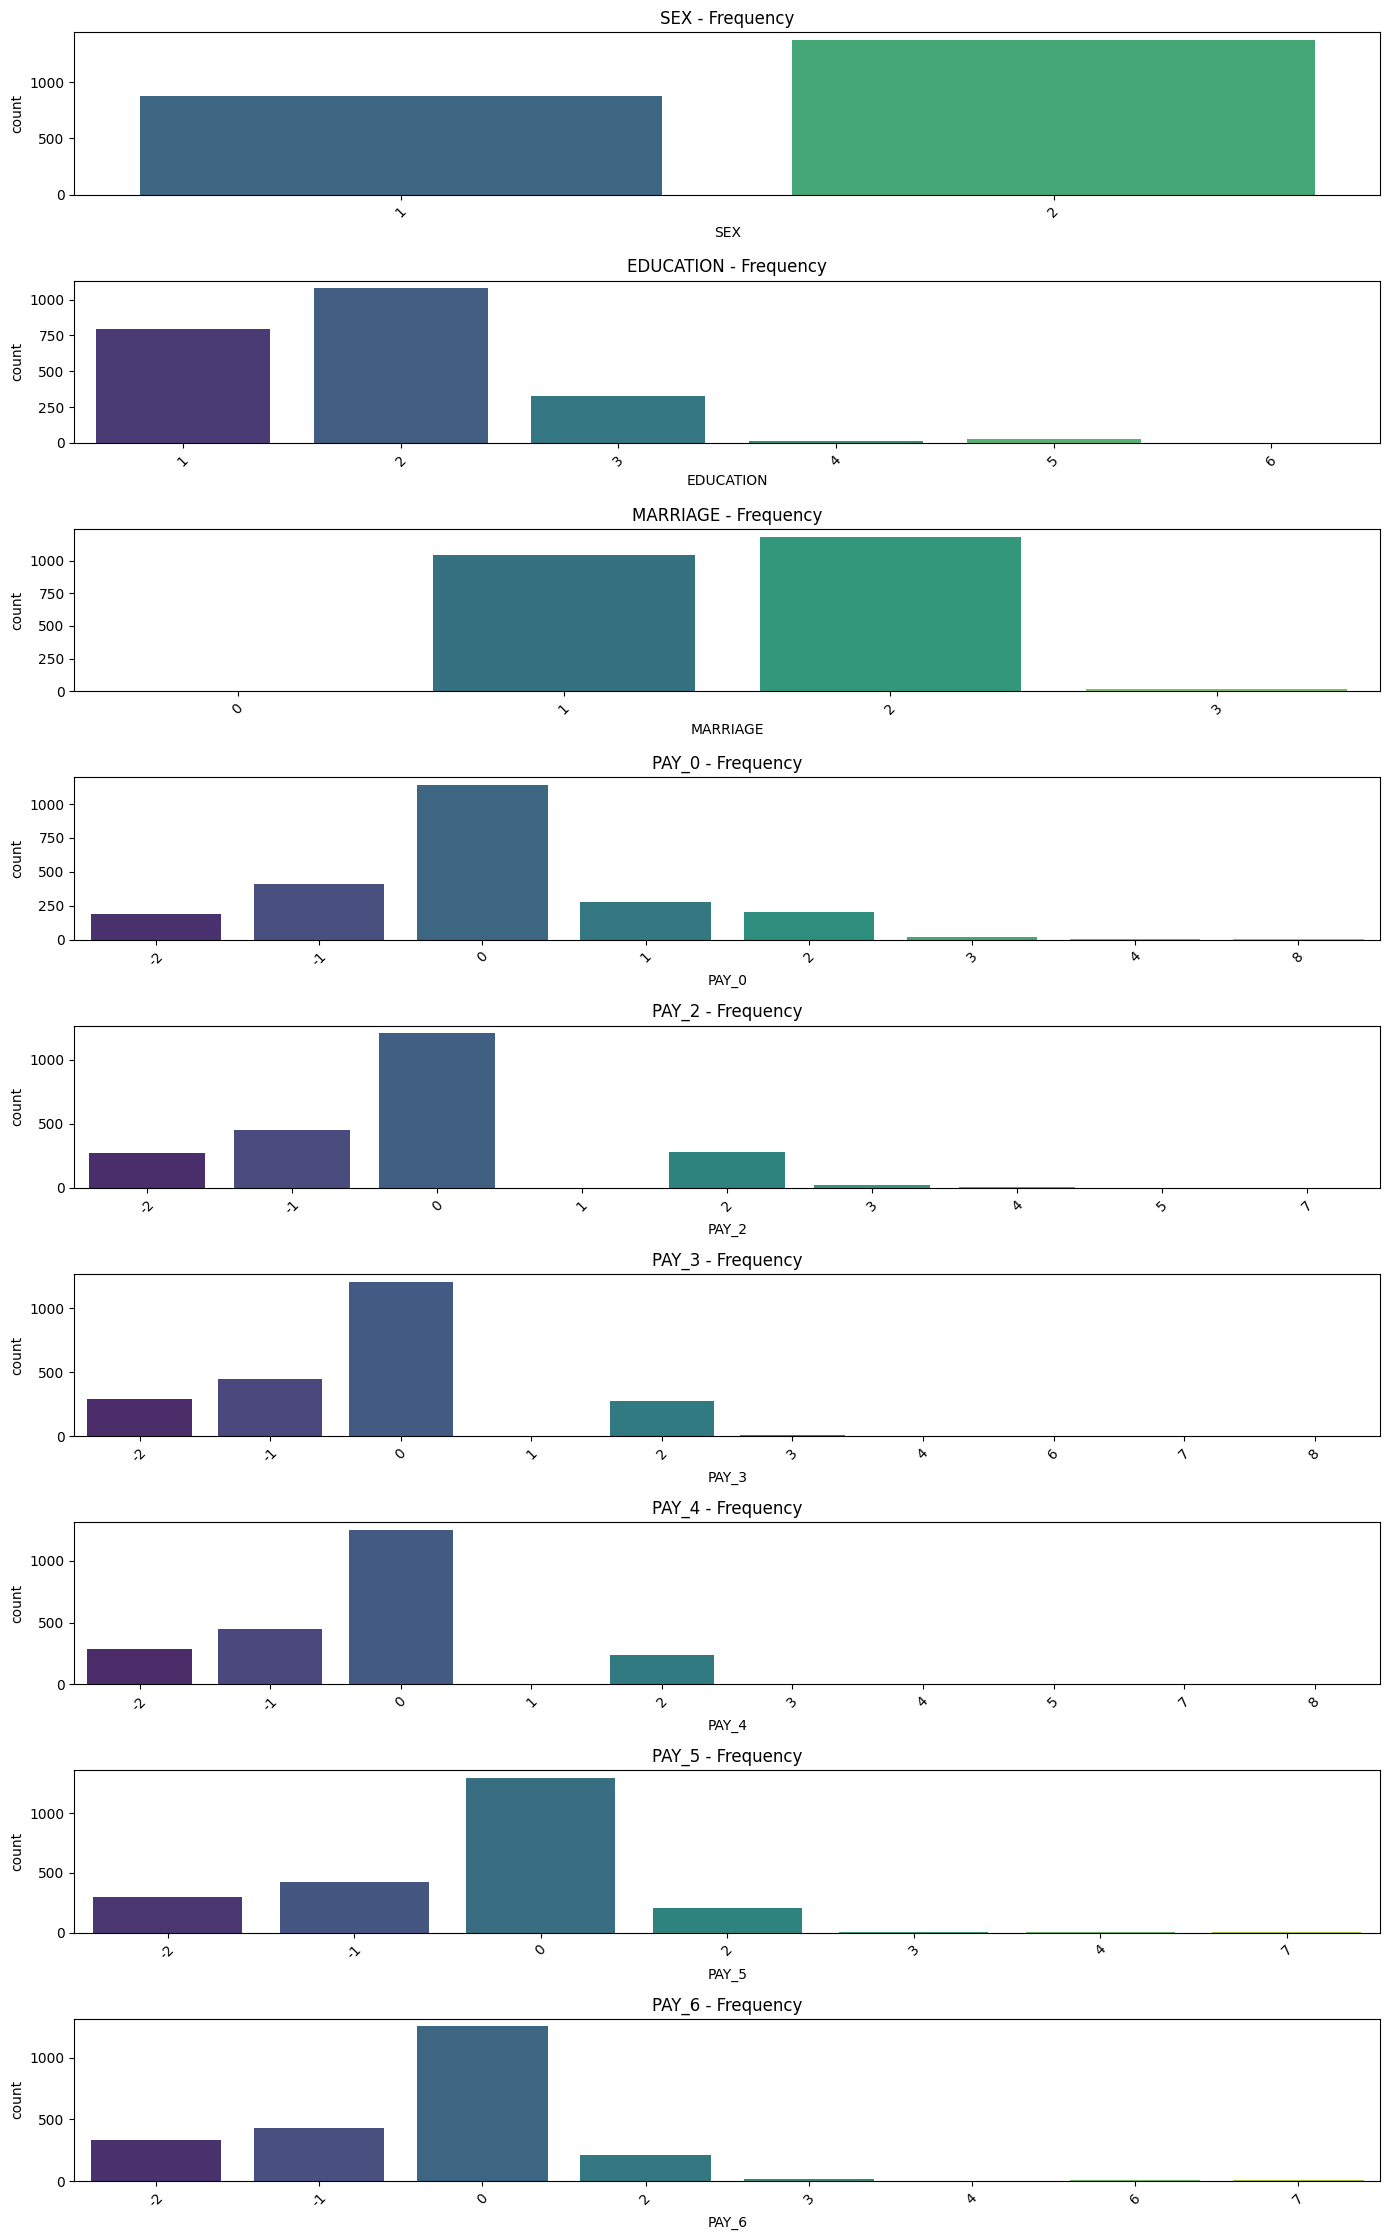


END OF FAST EDA REPORT


In [12]:
analysis=fast_eda_report(X_train_raw, target=TARGET)


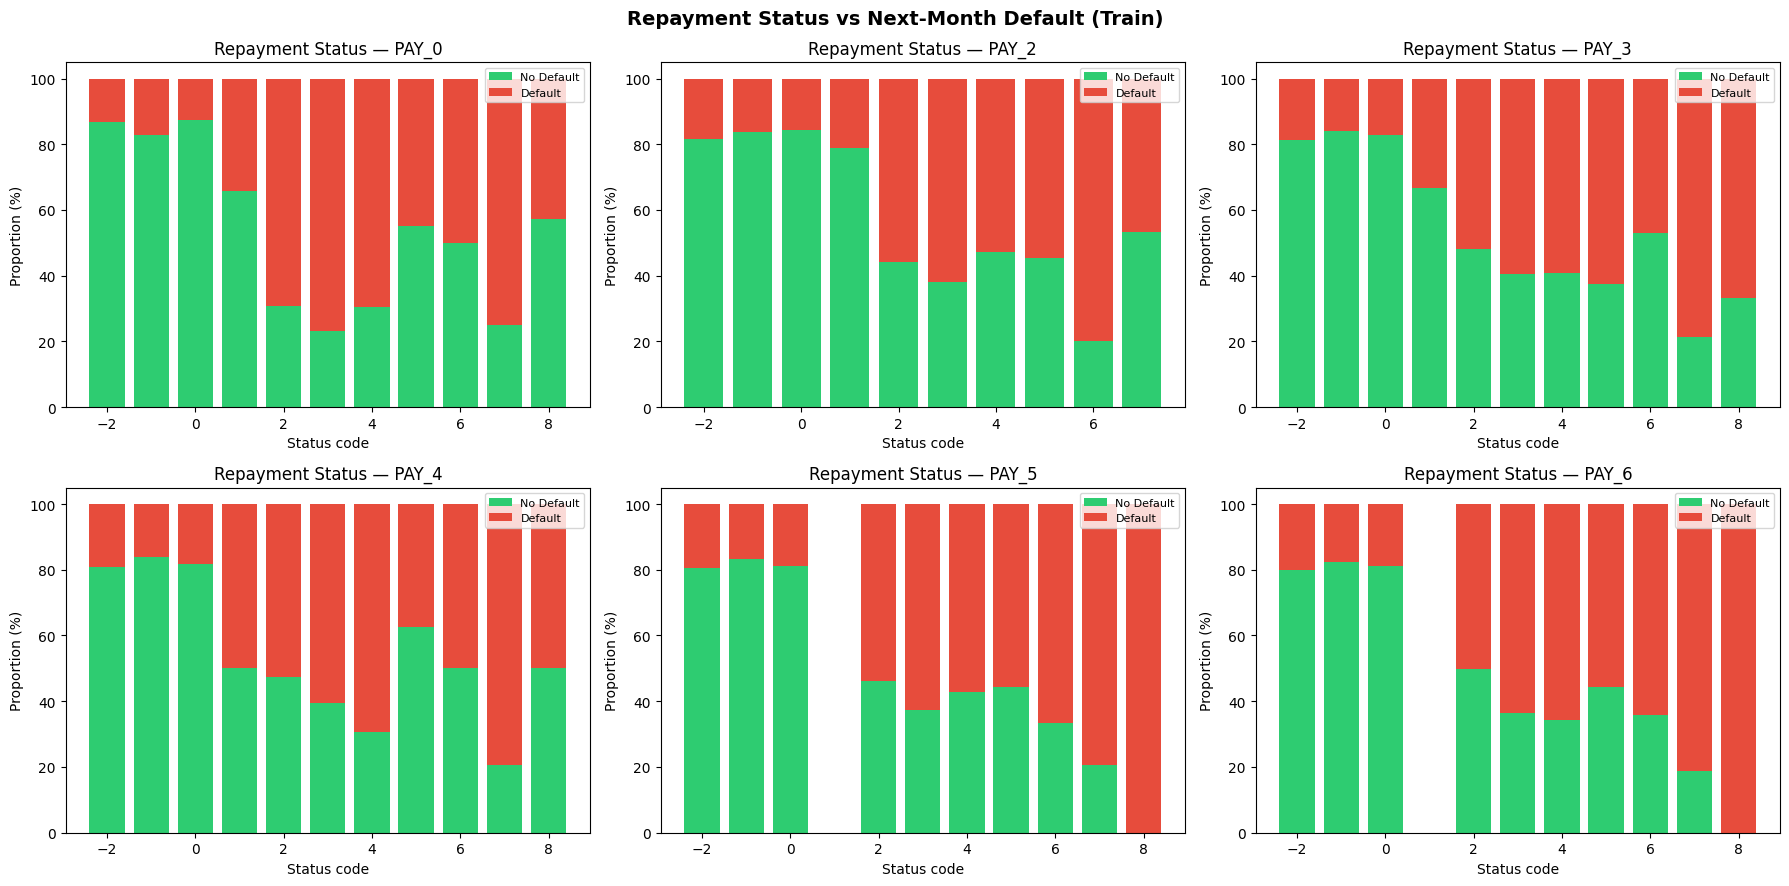

In [7]:
# Repayment status vs default rate (last 6 months)
pay_cols = [c for c in X_train_raw.columns if re.match(r"PAY_[0-9]", c)]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(pay_cols):
    ct = pd.crosstab(X_train_raw[col], y_train, normalize="index") * 100
    axes[i].bar(ct.index, ct.iloc[:, 0], label="No Default", color="#2ecc71")
    axes[i].bar(ct.index, ct.iloc[:, 1], bottom=ct.iloc[:, 0], label="Default", color="#e74c3c")
    axes[i].set_title(f"Repayment Status — {col}")
    axes[i].set_xlabel("Status code")
    axes[i].set_ylabel("Proportion (%)")
    axes[i].legend(fontsize=8)

plt.suptitle("Repayment Status vs Next-Month Default (Train)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Domain Feature Engineering

### Methodology

Credit risk is driven by **behavioural patterns** rather than raw bill amounts.  
We therefore engineer a set of financially meaningful features:

| Group | Features created | Rationale |
|-------|------------------|-----------|
| **Credit utilisation** | `UTIL_1` … `UTIL_6` | Bill amount / credit limit — classic risk signal |
| **Payment ratios** | `PAY_RATIO_1` … `PAY_RATIO_6` | Amount paid relative to bill |
| **Bill statistics** | `AVG_BILL`, `STD_BILL`, `MAX_BILL`, `BILL_TREND` | Level, volatility and recent trend |
| **Payment statistics** | `AVG_PAY_AMT`, `STD_PAY_AMT`, `PAY_TREND` | Payment consistency |
| **Delay aggregates** | `MAX_PAY_DELAY`, `AVG_PAY_DELAY`, `COUNT_DELAY_GE2`, `COUNT_DELAY_GT0` | Severity and frequency of late payments |
| **Over-limit flag** | `IS_OVER_LIMIT` | Binary indicator of limit breach |

Categorical clean-up (education / marriage codes) and a simplified payment-status mapping are also applied.

In [17]:
# 2. Stage 1: Domain Feature Engineering
X_train_eng= engineer_credit_features(X_train_raw)
X_test_eng  = engineer_credit_features(X_test_raw)
X_train_eng.drop(columns=["ID"], errors='ignore', inplace=True)
X_test_eng.drop(columns=["ID"], errors='ignore', inplace=True)

## 6. Preprocessing Pipeline

A lightweight, leakage-safe pipeline is built dynamically:

1. Missing-value indicator + median imputation  
2. Outlier flagging (3× IQR)  
3. Zero-inflated handling  
4. Percentile ranking for extreme skew  
5. Rare-label grouping + target encoding for low/high-cardinality categoricals and discrete variables

> **Note:** The custom transformers (`Flagnan3`, `Flagout2`, `RareLabelPandas`, `TargetEncoderFastPandas2`, etc.) from the original modular framework are replaced here by a self-contained, scikit-learn compatible pipeline so the notebook runs standalone on Colab.

In [18]:
# %%timeit -n 1 -r 1


# 3. Categorize features automatically
cl = classify_variables(X_train_eng, target_col=target)

# 4. Construct Dynamic Pipeline
steps = []

all_vars =cl['continuous'] + cl['discrete'] + cl['cat_low'] + cl['cat_high']
if all_vars:
    steps.append(('imp', Flagnan3(var=all_vars)))

if cl['continuous']:
    steps.append(('out', Flagout2(var=cl['continuous'], distance=3.0)))

zero_vars = [c for c in cl['zero_inflated'] if c in X_train_eng.columns]
if zero_vars:
    steps.append(('zero', ZeroInflatedTransformerPandas2(var=zero_vars)))

skew_vars = [c for c in cl['extreme_skew'] if c in X_train_eng.columns and c not in zero_vars]
if skew_vars:
    steps.append(('rank', PercentileRankerPandas2(var=skew_vars)))

if cl['cat_low']:
    steps.append(('rare_cat',  RareLabelPandas(var=cl['cat_low'], tol=0.02)))
    # steps.append(('oneh', Oneh(var=cl['cat_low'])))
    steps.append(('enc_cat', TargetEncoderFastPandas2(var=cl['cat_low'])))

if cl['discrete']:
    steps.append(('rare_disc',  RareLabelPandas(var=cl['discrete'], tol=0.02)))
    steps.append(('enc_disc', TargetEncoderFastPandas2(var=cl['discrete'])))

if cl['cat_high']:
    steps.append(('enc_high', TargetEncoderFastPandas2(var=cl['cat_high'])))

pipe0 = Pipeline(steps)

# 5. Fit & Transform
X_train2 = pipe0.fit_transform(X_train_eng, y_train)
X_test2  = pipe0.transform(X_test_eng)

print(f"✅ Transformed Train Shape: {X_train2.shape}")

plot_classification_correlations_plotly(X_train2, y_train, target_name=target, clase=1, top_n=35)

✅ Transformed Train Shape: (22473, 80)


## 7. Business Cost Function & Metrics

In [19]:
C_FN = 3.0   # Cost of missing a defaulter
C_FP = 1.0   # Cost of an unnecessary investigation


def financial_cost(y_true, y_probs, threshold=0.5, c_fn=C_FN, c_fp=C_FP):
    """Positive cost to be minimised."""
    y_pred = (np.asarray(y_probs) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return float(fn * c_fn + fp * c_fp)


def business_loss(y_true, y_pred, c_fn=C_FN, c_fp=C_FP):
    """Negative cost (for maximisation by scikit-learn scorers)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return -(fn * c_fn + fp * c_fp)


business_scorer = make_scorer(business_loss, greater_is_better=True)
print(f"Business costs defined: FN×{C_FN} + FP×{C_FP}")

Business costs defined: FN×3.0 + FP×1.0


## 8. Hyperparameter Optimisation (Optuna)

We optimise **Brier score** (proper scoring rule for probability quality) inside stratified 3-fold CV,  
with optional `SelectPercentile` feature selection tuned jointly.  
Early stopping + Optuna pruning keep the search efficient.

In [20]:
def objective_lgb(trial, X, y, cv=3, feature_selector=None, scoring="neg_brier_score"):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 5, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "objective": "binary",
        "is_unbalance": True,
        "random_state": RANDOM_STATE,
        "verbose": -1,
    }

    cv_split = StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for fold, (tr_idx, val_idx) in enumerate(cv_split.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        if feature_selector is not None:
            if feature_selector is SelectKBest:
                k = trial.suggest_int("selector_k", 10, X.shape[1])
                sel = SelectKBest(f_classif, k=k)
            else:
                p = trial.suggest_int("selector_percentile", 20, 100)
                sel = SelectPercentile(f_classif, percentile=p)
            X_tr_s = sel.fit_transform(X_tr, y_tr)
            X_val_s = sel.transform(X_val)
        else:
            X_tr_s, X_val_s = X_tr, X_val

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr_s, y_tr,
            eval_set=[(X_val_s, y_val)],
            eval_metric="binary_logloss",
            callbacks=[
                lgb.early_stopping(30, verbose=False),
                LightGBMPruningCallback(trial, "binary_logloss"),
            ],
        )
        probs = model.predict_proba(X_val_s)[:, 1]

        if scoring == "neg_brier_score":
            metric = -brier_score_loss(y_val, probs)
        elif scoring == "roc_auc":
            metric = roc_auc_score(y_val, probs)
        else:
            metric = -log_loss(y_val, probs)

        trial.report(-metric, fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
        scores.append(metric)

    return -np.mean(scores)


def optimize_lightgbm(X, y, n_trials=40, scoring="neg_brier_score",
                      feature_selector=SelectPercentile, study_name="lgb_study"):
    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(),
        study_name=study_name,
    )
    study.optimize(
        lambda t: objective_lgb(t, X, y, feature_selector=feature_selector, scoring=scoring),
        n_trials=n_trials,
        show_progress_bar=True,
    )
    return study


print("Starting LightGBM Optuna search (this may take a few minutes)...")
study_lgb = optimize_lightgbm(
    X_train2, pd.Series(y_train),
    n_trials=40,
    scoring="neg_brier_score",
    feature_selector=SelectPercentile,
    study_name="lgb_credit"
)
print("Best trial value:", study_lgb.best_value)
print("Best params:", study_lgb.best_params)

Starting LightGBM Optuna search (this may take a few minutes)...


  0%|          | 0/40 [00:00<?, ?it/s]

Best trial value: 0.1499289589812147
Best params: {'n_estimators': 507, 'learning_rate': 0.11022917994032369, 'num_leaves': 147, 'max_depth': 12, 'subsample': 0.6794303472203945, 'colsample_bytree': 0.9403989068859739, 'min_child_samples': 16, 'selector_percentile': 81}


In [21]:
def objective_cat(trial, X, y, cv=3, feature_selector=None, scoring="neg_brier_score"):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_seed": RANDOM_STATE,
        "verbose": 0,
        "early_stopping_rounds": 50,
        "eval_metric": "AUC",
    }

    cv_split = StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for fold, (tr_idx, val_idx) in enumerate(cv_split.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        if feature_selector is not None:
            if feature_selector is SelectKBest:
                k = trial.suggest_int("selector_k", 10, X.shape[1])
                sel = SelectKBest(f_classif, k=k)
            else:
                p = trial.suggest_int("selector_percentile", 10, 100)
                sel = SelectPercentile(f_classif, percentile=p)
            X_tr_s = sel.fit_transform(X_tr, y_tr)
            X_val_s = sel.transform(X_val)
        else:
            X_tr_s, X_val_s = X_tr, X_val

        model = CatBoostClassifier(**params)
        model.fit(
            X_tr_s, y_tr,
            eval_set=[(X_val_s, y_val)],
            callbacks=[CatBoostPruningCallback(trial, "AUC")],
            verbose=False,
        )
        probs = model.predict_proba(X_val_s)[:, 1]

        if scoring == "neg_brier_score":
            metric = -brier_score_loss(y_val, probs)
        elif scoring == "roc_auc":
            metric = roc_auc_score(y_val, probs)
        else:
            metric = -log_loss(y_val, probs)

        trial.report(-metric, fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
        scores.append(metric)

    return -np.mean(scores)


def optimize_catboost(X, y, n_trials=30, scoring="neg_brier_score",
                      feature_selector=SelectPercentile, study_name="cat_study"):
    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(),
        study_name=study_name,
    )
    study.optimize(
        lambda t: objective_cat(t, X, y, feature_selector=feature_selector, scoring=scoring),
        n_trials=n_trials,
        show_progress_bar=True,
    )
    return study


print("Starting CatBoost Optuna search...")
study_cat = optimize_catboost(
    X_train2, pd.Series(y_train),
    n_trials=30,
    scoring="neg_brier_score",
    feature_selector=SelectPercentile,
    study_name="cat_credit"
)
print("Best trial value:", study_cat.best_value)
print("Best params:", study_cat.best_params)

Starting CatBoost Optuna search...


  0%|          | 0/30 [00:00<?, ?it/s]

Best trial value: 0.13267791880194482
Best params: {'iterations': 452, 'learning_rate': 0.03485100084234865, 'depth': 5, 'l2_leaf_reg': 0.2770564945266657, 'border_count': 115, 'selector_percentile': 86}


## 9. Final Model Training (Calibration + Threshold Tuning)

In [22]:
def train_final_model_binary(
    study, X_train, y_train, X_test, y_test,
    model_type="lgb", calibrate=True, use_selector=True, save_dir="models/"
):
    os.makedirs(save_dir, exist_ok=True)
    best_params = study.best_params.copy()

    selector = None
    if use_selector:
        if "selector_k" in best_params:
            k = best_params.pop("selector_k")
            selector = SelectKBest(f_classif, k=k)
        elif "selector_percentile" in best_params:
            p = best_params.pop("selector_percentile")
            selector = SelectPercentile(f_classif, percentile=p)

    if model_type == "lgb":
        clf = lgb.LGBMClassifier(
            **best_params, objective="binary", is_unbalance=True,
            random_state=RANDOM_STATE, verbose=-1
        )
    else:
        clf = CatBoostClassifier(**best_params, random_seed=RANDOM_STATE, verbose=0)

    if selector is not None:
        pipeline = Pipeline([("selector", selector), ("clf", clf)])
    else:
        pipeline = clf

    if calibrate:
        base = CalibratedClassifierCV(
            pipeline, method="isotonic",
            cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
        )
    else:
        base = pipeline

    final_model = TunedThresholdClassifierCV(
        base,
        scoring=business_scorer,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        thresholds=np.linspace(0.02, 0.80, 200),
    )
    final_model.fit(X_train, y_train)

    joblib.dump(final_model, os.path.join(save_dir, f"{model_type}_final_model.joblib"))
    joblib.dump(study, os.path.join(save_dir, f"{model_type}_study.joblib"))

    thr = final_model.best_threshold_
    probs = final_model.predict_proba(X_test)[:, 1]
    preds = (probs >= thr).astype(int)

    print("=" * 60)
    print(f"FINAL TEST RESULTS — {model_type.upper()}")
    print("=" * 60)
    print(f"ROC-AUC        : {roc_auc_score(y_test, probs):.4f}")
    print(f"Brier Score    : {brier_score_loss(y_test, probs):.4f}")
    print(f"Best Threshold : {thr:.4f}")
    print(f"Financial Cost : {financial_cost(y_test, probs, thr):,.0f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds, digits=4))

    return final_model


final_lgb = train_final_model_binary(
    study_lgb, X_train2, y_train, X_test2, y_test,
    model_type="lgb", calibrate=True, use_selector=True, save_dir="lgb"
)

final_cat = train_final_model_binary(
    study_cat, X_train2, y_train, X_test2, y_test,
    model_type="cat", calibrate=True, use_selector=True, save_dir="cat"
)

FINAL TEST RESULTS — LGB
ROC-AUC        : 0.7636
Brier Score    : 0.1390
Best Threshold : 0.2552
Financial Cost : 3,126

Classification Report:
              precision    recall  f1-score   support

           0     0.8721    0.8288    0.8499      5834
           1     0.4872    0.5724    0.5263      1658

    accuracy                         0.7720      7492
   macro avg     0.6796    0.7006    0.6881      7492
weighted avg     0.7869    0.7720    0.7783      7492

FINAL TEST RESULTS — CAT
ROC-AUC        : 0.7838
Brier Score    : 0.1340
Best Threshold : 0.2709
Financial Cost : 3,041

Classification Report:
              precision    recall  f1-score   support

           0     0.8720    0.8557    0.8637      5834
           1     0.5235    0.5579    0.5401      1658

    accuracy                         0.7898      7492
   macro avg     0.6977    0.7068    0.7019      7492
weighted avg     0.7948    0.7898    0.7921      7492



## 10. Blending & Stacking

In [23]:
# Extract best params & selectors
best_lgb = study_lgb.best_params.copy()
best_cat = study_cat.best_params.copy()


def extract_selector(params):
    sel = None
    if "selector_k" in params:
        k = params.pop("selector_k")
        sel = SelectKBest(f_classif, k=k)
    elif "selector_percentile" in params:
        p = params.pop("selector_percentile")
        sel = SelectPercentile(f_classif, percentile=p)
    return sel


selector_lgb = extract_selector(best_lgb)
selector_cat = extract_selector(best_cat)

lgb_base = lgb.LGBMClassifier(
    **best_lgb, objective="binary", is_unbalance=True,
    random_state=RANDOM_STATE, verbose=-1
)
cat_base = CatBoostClassifier(**best_cat, random_seed=RANDOM_STATE, verbose=0)


def get_oof_probs(X, y, model, selector=None, n_splits=5):
    oof = np.zeros(len(y))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for tr_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr = y.iloc[tr_idx]
        if selector is not None:
            sel = clone(selector)
            X_tr_s = sel.fit_transform(X_tr, y_tr)
            X_val_s = sel.transform(X_val)
        else:
            X_tr_s, X_val_s = X_tr, X_val
        m = clone(model)
        m.fit(X_tr_s, y_tr)
        oof[val_idx] = m.predict_proba(X_val_s)[:, 1]
    return oof


print("Generating OOF probabilities...")
lgb_oof = get_oof_probs(X_train2, y_train, lgb_base, selector=selector_lgb)
cat_oof = get_oof_probs(X_train2, y_train, cat_base, selector=selector_cat)

# Joint optimisation of blend weight + threshold on OOF
def joint_loss(z):
    w, t = z
    blend = w * lgb_oof + (1.0 - w) * cat_oof
    return financial_cost(y_train, blend, threshold=t)


res = minimize(
    joint_loss, x0=[0.5, 0.30],
    bounds=[(0.0, 1.0), (0.02, 0.80)],
    method="Nelder-Mead",
    options={"xatol": 1e-4, "fatol": 1.0, "maxiter": 500},
)
best_w_lgb, best_thr_blend = float(res.x[0]), float(res.x[1])
print(f"Blend weight LightGBM: {best_w_lgb:.4f} | Threshold: {best_thr_blend:.4f}")

# Test evaluation
lgb_test_probs = final_lgb.predict_proba(X_test2)[:, 1]
cat_test_probs = final_cat.predict_proba(X_test2)[:, 1]
blend_test_probs = best_w_lgb * lgb_test_probs + (1 - best_w_lgb) * cat_test_probs
blend_preds = (blend_test_probs >= best_thr_blend).astype(int)

print("\n" + "=" * 60)
print("BLENDING RESULTS")
print("=" * 60)
print(f"ROC-AUC        : {roc_auc_score(y_test, blend_test_probs):.4f}")
print(f"Brier Score    : {brier_score_loss(y_test, blend_test_probs):.4f}")
print(f"Best Threshold : {best_thr_blend:.4f}")
print(f"Financial Cost : {financial_cost(y_test, blend_test_probs, best_thr_blend):,.0f}")
print(classification_report(y_test, blend_preds, digits=4))

Generating OOF probabilities...
Blend weight LightGBM: 0.0000 | Threshold: 0.3009

BLENDING RESULTS
ROC-AUC        : 0.7838
Brier Score    : 0.1340
Best Threshold : 0.3009
Financial Cost : 3,085
              precision    recall  f1-score   support

           0     0.8672    0.8718    0.8695      5834
           1     0.5403    0.5302    0.5352      1658

    accuracy                         0.7962      7492
   macro avg     0.7037    0.7010    0.7023      7492
weighted avg     0.7948    0.7962    0.7955      7492



In [24]:
# Stacking
estimators = [
    ("lgb", lgb.LGBMClassifier(
        **best_lgb, objective="binary", is_unbalance=True,
        random_state=RANDOM_STATE, verbose=-1)),
    ("cat", CatBoostClassifier(**best_cat, random_seed=RANDOM_STATE, verbose=0)),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(C=0.5, max_iter=1000),
    cv=5,
    stack_method="predict_proba",
)

print("Training StackingClassifier...")
stack.fit(X_train2, y_train)

stack_tuned = TunedThresholdClassifierCV(
    estimator=stack,
    scoring=business_scorer,
    cv=5,
    thresholds=np.linspace(0.02, 0.80, 200),
    refit=True,
)
stack_tuned.fit(X_train2, y_train)

stack_test_probs = stack_tuned.predict_proba(X_test2)[:, 1]
stack_preds = stack_tuned.predict(X_test2)

print(f"Stack threshold : {stack_tuned.best_threshold_:.4f}")
print(f"Financial Cost  : {financial_cost(y_test, stack_test_probs, stack_tuned.best_threshold_):,.0f}")
print(classification_report(y_test, stack_preds, digits=4))

Training StackingClassifier...
Stack threshold : 0.2317
Financial Cost  : 3,012
              precision    recall  f1-score   support

           0     0.8747    0.8483    0.8613      5834
           1     0.5174    0.5724    0.5435      1658

    accuracy                         0.7872      7492
   macro avg     0.6961    0.7103    0.7024      7492
weighted avg     0.7956    0.7872    0.7910      7492



In [29]:
from autogluon.tabular import TabularPredictor
from autogluon.core.metrics import make_scorer
from scipy.optimize import minimize_scalar


# 1. Prepare data

label = "target"
train_data_ag = X_train2.copy()
train_data_ag[label] = y_train

test_data_ag = X_test2.copy()
test_data_ag[label] = y_test

# 2. Training metric (threshold-free)

ag_brier = make_scorer(
    name="brier_binary",
    score_func=brier_score_loss,
    optimum=0.0,
    greater_is_better=False,
    needs_proba=True
)


# 3. Train

print("Training AutoGluon (best_quality, generous time_limit)...")

predictor = TabularPredictor(
    label=label,
    eval_metric=ag_brier,
    problem_type="binary",
    path="ag_binary_long",
    verbosity=2
)

predictor.fit(
    train_data=train_data_ag,
    presets="best_quality",
    time_limit=600,
    num_bag_folds=5,
    num_stack_levels=1,
    calibrate_decision_threshold=True,
    dynamic_stacking=False
)

print(f"\nBest model          : {predictor.model_best}")
print(f"AutoGluon threshold : {predictor.decision_threshold:.4f}")


# 4. Probabilities

oof_probs = predictor.predict_proba_oof(as_multiclass=False).values.ravel()
test_probs = predictor.predict_proba(X_test2, as_multiclass=False).values.ravel()

print(f"OOF shape  : {oof_probs.shape}")
print(f"Test shape : {test_probs.shape}")


# 5. Thresholds to compare

thr_ag = float(predictor.decision_threshold)

def cost_obj(t):
    return financial_cost(y_train, oof_probs, t)

res = minimize_scalar(cost_obj, bounds=(0.02, 0.90), method="bounded")
thr_cost = float(res.x)

def neg_f1(t):
    preds = (oof_probs >= t).astype(int)
    return -f1_score(y_train, preds, average="macro", zero_division=0)

res_f1 = minimize_scalar(neg_f1, bounds=(0.02, 0.90), method="bounded")
thr_f1 = float(res_f1.x)

print("\nThresholds:")
print(f"  Default 0.50          : 0.5000")
print(f"  AutoGluon calibrated  : {thr_ag:.4f}")
print(f"  OOF Cost-tuned        : {thr_cost:.4f}")
print(f"  OOF Macro-F1-tuned    : {thr_f1:.4f}")

# -------------------------------------------------
# 6. Evaluation on TEST (once)
# -------------------------------------------------
strategies = {
    "Default 0.50": 0.50,
    "AutoGluon calibrated": thr_ag,
    "OOF Cost-tuned": thr_cost,
    "OOF Macro-F1-tuned": thr_f1
}

rows = []
for name, thr in strategies.items():
    preds = (test_probs >= thr).astype(int)
    rows.append({
        "Strategy": name,
        "Threshold": round(thr, 4),
        "ROC-AUC": round(roc_auc_score(y_test, test_probs), 4),
        "Brier": round(brier_score_loss(y_test, test_probs), 4),
        "Macro F1": round(f1_score(y_test, preds, average="macro", zero_division=0), 4),
        "Balanced Acc": round(balanced_accuracy_score(y_test, preds), 4),
        "Financial Cost": f"{financial_cost(y_test, test_probs, thr):,.0f}",
        "Cost / sample": round(financial_cost(y_test, test_probs, thr) / len(y_test), 4)
    })

ag_summary = pd.DataFrame(rows)
print("\n" + "=" * 80)
print("AutoGluon – Test Results")
print("=" * 80)
print(ag_summary.to_string(index=False))

print("\nClassification Report (OOF Cost-tuned):")
print(classification_report(y_test, (test_probs >= thr_cost).astype(int)))

# -------------------------------------------------
# 7. Honesty check (OOF vs Test)
# -------------------------------------------------
cost_oof_05    = financial_cost(y_train, oof_probs, 0.50)
cost_oof_tuned = financial_cost(y_train, oof_probs, thr_cost)
cost_test_05   = financial_cost(y_test, test_probs, 0.50)
cost_test_tuned = financial_cost(y_test, test_probs, thr_cost)

print("\nHonesty check (Financial Cost):")
print(f"  OOF  0.50 → tuned : {cost_oof_05:,.0f} → {cost_oof_tuned:,.0f}")
print(f"  Test 0.50 → tuned : {cost_test_05:,.0f} → {cost_test_tuned:,.0f}")

Verbosity: 2 (Standard Logging)


Training AutoGluon (best_quality, generous time_limit)...


=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.94 GB / 12.67 GB (86.3%)
Disk Space Avail:   204.14 GB / 225.83 GB (90.4%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/content/ag_binary_long"
Train Data Rows:    22473
Train Data Columns: 80
Label Column:       target
Problem Type:       binary
Preprocessing data...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:   


Best model          : WeightedEnsemble_L3
AutoGluon threshold : 0.5000
OOF shape  : (22473,)
Test shape : (7492,)

Thresholds:
  Default 0.50          : 0.5000
  AutoGluon calibrated  : 0.5000
  OOF Cost-tuned        : 0.2728
  OOF Macro-F1-tuned    : 0.3401

AutoGluon – Test Results
            Strategy  Threshold  ROC-AUC  Brier  Macro F1  Balanced Acc Financial Cost  Cost / sample
        Default 0.50     0.5000   0.7804 0.1345    0.6854        0.6608          3,421         0.4566
AutoGluon calibrated     0.5000   0.7804 0.1345    0.6854        0.6608          3,421         0.4566
      OOF Cost-tuned     0.2728   0.7804 0.1345    0.7025        0.7080          3,030         0.4044
  OOF Macro-F1-tuned     0.3401   0.7804 0.1345    0.7064        0.6982          3,095         0.4131

Classification Report (OOF Cost-tuned):
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      5834
           1       0.52      0.56      0.54      1658


## 11. Model Comparison Dashboard

In [30]:
probs_dict = {
    "LightGBM":  final_lgb.predict_proba(X_test2)[:, 1],
    "CatBoost":  final_cat.predict_proba(X_test2)[:, 1],
    "Blending":  blend_test_probs,
    "Stacking":  stack_test_probs,

    "AutoGluon": test_probs,
}

thresholds_dict = {
    "LightGBM":  float(final_lgb.best_threshold_),
    "CatBoost":  float(final_cat.best_threshold_),
    "Blending":  float(best_thr_blend),
    "Stacking":  float(stack_tuned.best_threshold_),

    "AutoGluon": float(thr_cost),
}

rows = []
for name in probs_dict:
    probs = probs_dict[name]
    thr = thresholds_dict[name]
    preds = (probs >= thr).astype(int)
    cost = financial_cost(y_test, probs, thr)
    rows.append({
        "Model": name,
        "Threshold": round(thr, 4),
        "ROC-AUC": round(roc_auc_score(y_test, probs), 4),
        "Brier": round(brier_score_loss(y_test, probs), 4),
        "Macro F1": round(f1_score(y_test, preds, average="macro", zero_division=0), 4),
        "Balanced Acc": round(balanced_accuracy_score(y_test, preds), 4),
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Financial Cost": cost,
        "Cost / sample": round(cost / len(y_test), 4),
    })

summary_df = pd.DataFrame(rows).sort_values("Financial Cost").reset_index(drop=True)
print("=" * 90)
print("FINAL MODEL RANKING (sorted by Financial Cost)")
print("=" * 90)
print(summary_df.to_string(index=False))

best_name = summary_df.iloc[0]["Model"]
print(f"\nBest model by business cost: {best_name}")

FINAL MODEL RANKING (sorted by Financial Cost)
    Model  Threshold  ROC-AUC  Brier  Macro F1  Balanced Acc  Accuracy  Financial Cost  Cost / sample
 Stacking     0.2317   0.7840 0.1345    0.7024        0.7103    0.7872          3012.0         0.4020
AutoGluon     0.2728   0.7804 0.1345    0.7025        0.7080    0.7896          3030.0         0.4044
 CatBoost     0.2709   0.7838 0.1340    0.7019        0.7068    0.7898          3041.0         0.4059
 Blending     0.3009   0.7838 0.1340    0.7023        0.7010    0.7962          3085.0         0.4118
 LightGBM     0.2552   0.7636 0.1390    0.6881        0.7006    0.7720          3126.0         0.4172

Best model by business cost: Stacking


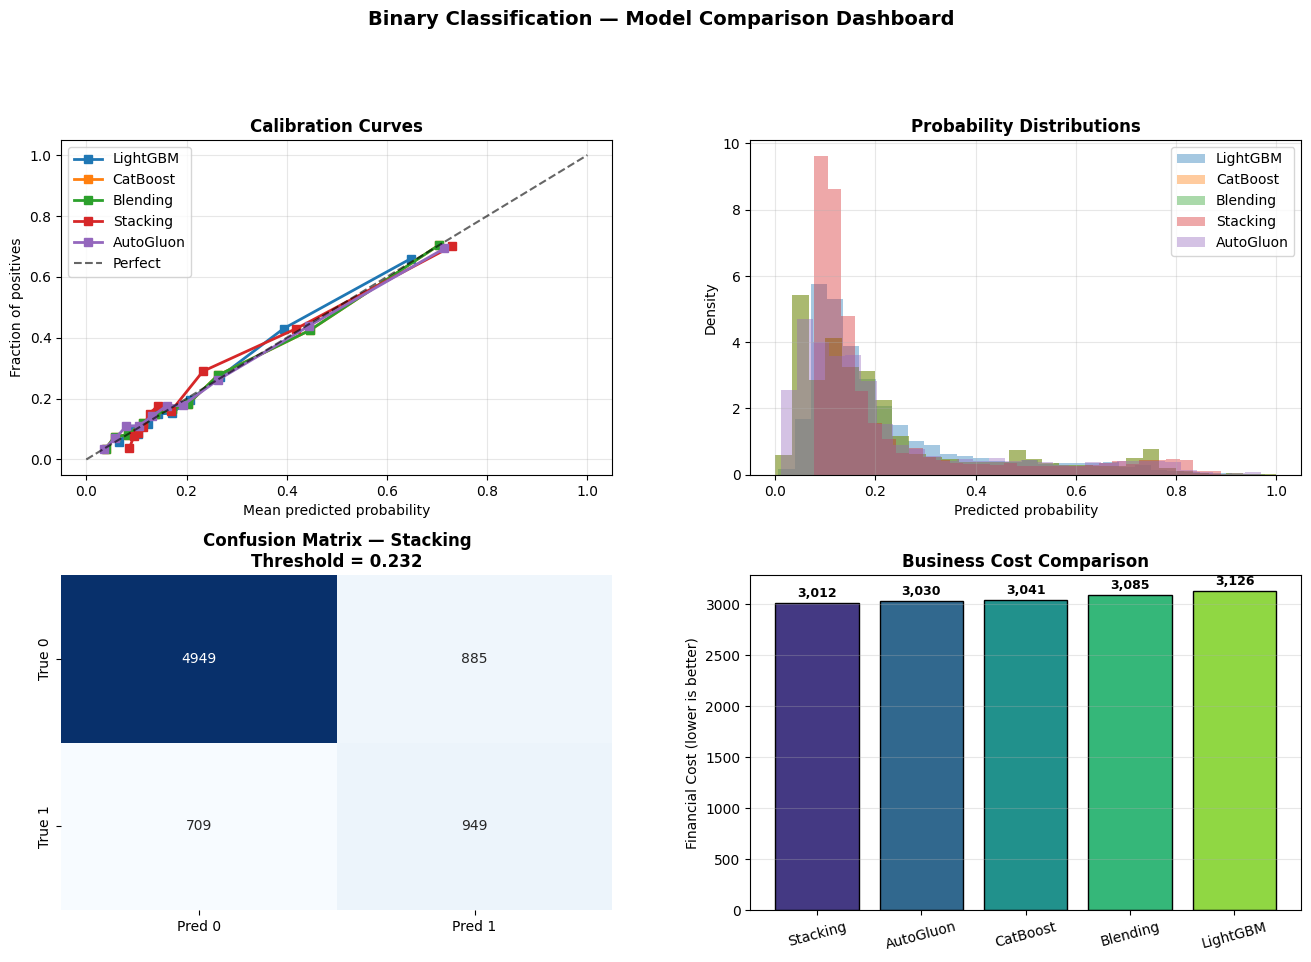


Classification Report — Best Model:
              precision    recall  f1-score   support

           0     0.8747    0.8483    0.8613      5834
           1     0.5174    0.5724    0.5435      1658

    accuracy                         0.7872      7492
   macro avg     0.6961    0.7103    0.7024      7492
weighted avg     0.7956    0.7872    0.7910      7492



In [31]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.30, wspace=0.25)

# Calibration
ax1 = fig.add_subplot(gs[0, 0])
for name, probs in probs_dict.items():
    frac, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="quantile")
    ax1.plot(mean_pred, frac, "s-", label=name, linewidth=2)
ax1.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Perfect")
ax1.set_xlabel("Mean predicted probability")
ax1.set_ylabel("Fraction of positives")
ax1.set_title("Calibration Curves", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Probability distributions
ax2 = fig.add_subplot(gs[0, 1])
for name, probs in probs_dict.items():
    ax2.hist(probs, bins=30, alpha=0.4, label=name, density=True)
ax2.set_xlabel("Predicted probability")
ax2.set_ylabel("Density")
ax2.set_title("Probability Distributions", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Confusion matrix of winner
ax3 = fig.add_subplot(gs[1, 0])
best_probs = probs_dict[best_name]
best_thr = thresholds_dict[best_name]
best_preds = (best_probs >= best_thr).astype(int)
cm = confusion_matrix(y_test, best_preds, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3, cbar=False,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
ax3.set_title(f"Confusion Matrix — {best_name}\nThreshold = {best_thr:.3f}", fontweight="bold")

# Cost bars
ax4 = fig.add_subplot(gs[1, 1])
names = summary_df["Model"].tolist()
costs = summary_df["Financial Cost"].tolist()
bars = ax4.bar(names, costs, color=sns.color_palette("viridis", len(names)), edgecolor="black")
ax4.set_ylabel("Financial Cost (lower is better)")
ax4.set_title("Business Cost Comparison", fontweight="bold")
ax4.grid(True, alpha=0.3, axis="y")
for bar, c in zip(bars, costs):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(costs)*0.01,
             f"{c:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.xticks(rotation=15)

plt.suptitle("Binary Classification — Model Comparison Dashboard", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nClassification Report — Best Model:")
print(classification_report(y_test, best_preds, digits=4))

In [32]:
!unzip artifacts_binary.zip

Archive:  artifacts_binary.zip
   creating: artifacts_binary/
  inflating: artifacts_binary/study_cat.joblib  
  inflating: artifacts_binary/binary_lgb_production_bundle.joblib  
  inflating: artifacts_binary/model_comparison_20261003_0001.csv  
  inflating: artifacts_binary/lgb_oof.npy  
  inflating: artifacts_binary/requirements.txt  
  inflating: artifacts_binary/cat_oof.npy  
  inflating: artifacts_binary/run_meta.json  
  inflating: artifacts_binary/study_lgb.joblib  


In [34]:
# Reload the best model from a previous run
# We keep the production bundle that achieved the lowest financial cost
# and treat this notebook as a control / documentation run.
# Do not re-train or overwrite the bundle unless the data or feature engineering changes.

import joblib
import os

BUNDLE_PATH = "/content/artifacts_binary/binary_lgb_production_bundle.joblib"

if not os.path.exists(BUNDLE_PATH):
    raise FileNotFoundError(
        f"{BUNDLE_PATH} not found. "
        "Place the best-run bundle in the working directory before continuing."
    )

bundle = joblib.load(BUNDLE_PATH)

final_lgb  = bundle["model"]
THRESHOLD  = float(bundle["optimal_threshold"])
C_FN       = float(bundle.get("C_FN", 3.0))
C_FP       = float(bundle.get("C_FP", 1.0))
RAW_COLS   = list(bundle["raw_feature_names"])
MODEL_COLS = list(bundle["model_feature_names"])
metrics    = bundle.get("benchmark_metrics", {})

print("Production bundle loaded")
print(f"Model type      : {type(final_lgb).__name__}")
print(f"Threshold       : {THRESHOLD:.4f}")
print(f"C_FN / C_FP     : {C_FN} / {C_FP}")
print(f"Benchmark AUC   : {metrics.get('ROC_AUC', 'n/a')}")
print(f"Benchmark Brier : {metrics.get('Brier', 'n/a')}")
print(f"Benchmark Cost  : {metrics.get('Financial_Cost_Test', 'n/a')}")
print(f"Version         : {bundle.get('bundle_version', 'n/a')}")

Production bundle loaded
Model type      : TunedThresholdClassifierCV
Threshold       : 0.2669
C_FN / C_FP     : 3.0 / 1.0
Benchmark AUC   : 0.7814349706647497
Benchmark Brier : 0.134071990647847
Benchmark Cost  : 2990.0
Version         : 1.0_PRODUCTION_LGB_BINARY


## 12. SHAP Explanations (LightGBM — Best Model)

We explain the final calibrated LightGBM model using TreeSHAP.  
Global importance, beeswarm summary and a waterfall plot for a single instance are shown.

In [ ]:
# # Extract the underlying LightGBM estimator for SHAP
# # (TunedThresholdClassifierCV → CalibratedClassifierCV → Pipeline → LGBMClassifier)
# try:
#     # Navigate the nested structure
#     calibrated = final_lgb.estimator_
#     if hasattr(calibrated, "calibrated_classifiers_"):
#         # Take first fold's base estimator
#         base_est = calibrated.calibrated_classifiers_[0].estimator
#     else:
#         base_est = calibrated

#     if hasattr(base_est, "named_steps"):
#         # Pipeline with selector + clf
#         lgb_for_shap = base_est.named_steps["clf"]
#         # Apply selector to get the feature subset used by the model
#         sel = base_est.named_steps["selector"]
#         X_train_shap = pd.DataFrame(
#             sel.transform(X_train2),
#             columns=X_train2.columns[sel.get_support()],
#             index=X_train2.index
#         )
#         X_test_shap = pd.DataFrame(
#             sel.transform(X_test2),
#             columns=X_test2.columns[sel.get_support()],
#             index=X_test2.index
#         )
#     else:
#         lgb_for_shap = base_est
#         X_train_shap = X_train2
#         X_test_shap = X_test2

#     # Background sample
#     background = X_train_shap.sample(n=min(200, len(X_train_shap)), random_state=RANDOM_STATE)
#     X_explain = X_test_shap.sample(n=min(400, len(X_test_shap)), random_state=RANDOM_STATE)

#     explainer = shap.TreeExplainer(
#         lgb_for_shap,
#         data=background,
#         feature_perturbation="tree_path_dependent",
#         model_output="raw",
#     )
#     shap_values = explainer.shap_values(X_explain)

#     # Global bar plot
#     plt.figure(figsize=(10, 6))
#     shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)
#     plt.title("Global SHAP Feature Importance (LightGBM)")
#     plt.tight_layout()
#     plt.show()

#     # Beeswarm
#     plt.figure(figsize=(10, 7))
#     shap.summary_plot(shap_values, X_explain, show=False)
#     plt.title("SHAP Summary (Beeswarm)")
#     plt.tight_layout()
#     plt.show()

#     # Waterfall for one instance
#     idx = 50
#     shap.waterfall_plot(
#         shap.Explanation(
#             values=shap_values[idx],
#             base_values=explainer.expected_value,
#             data=X_explain.iloc[idx].values,
#             feature_names=X_explain.columns.tolist(),
#         ),
#         show=False,
#         max_display=15,
#     )
#     plt.title(f"SHAP Waterfall — Instance {idx}")
#     plt.tight_layout()
#     plt.show()

# except Exception as e:
#     print("SHAP explanation skipped due to nested estimator structure:")
#     print(e)
#     print("\nTip: retrain a plain LGBMClassifier on the selected features for cleaner SHAP.")

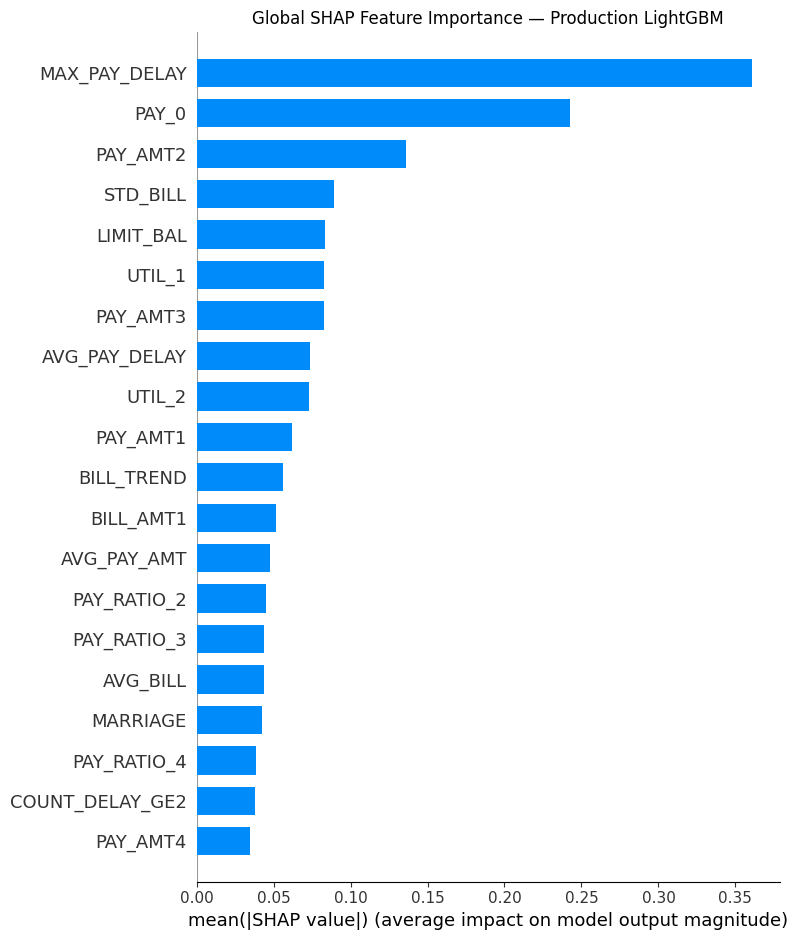

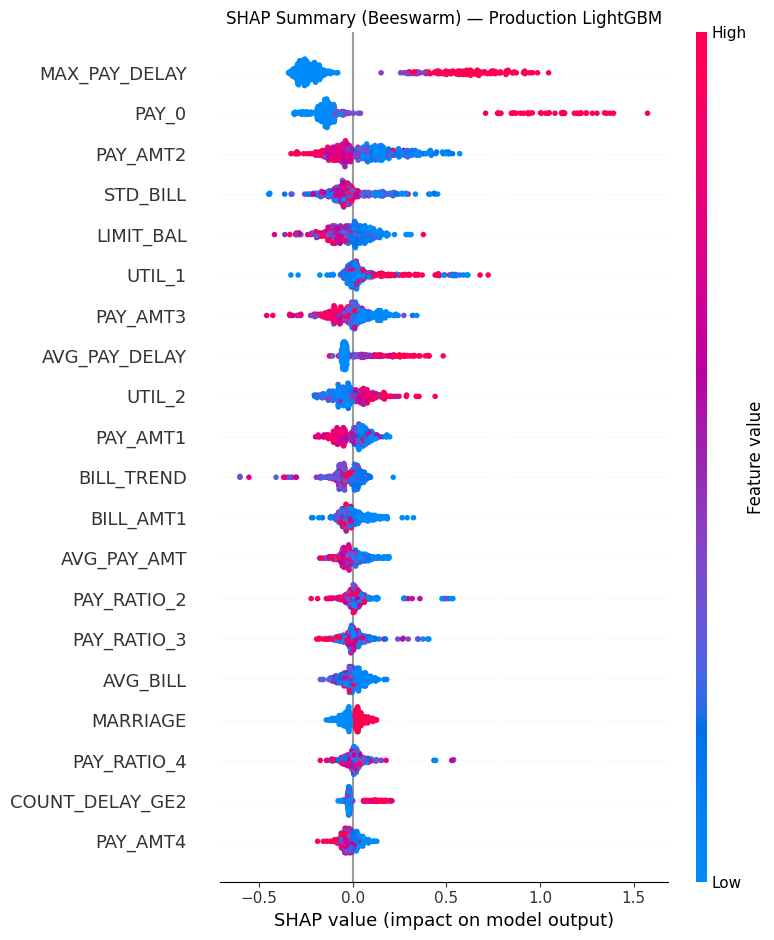

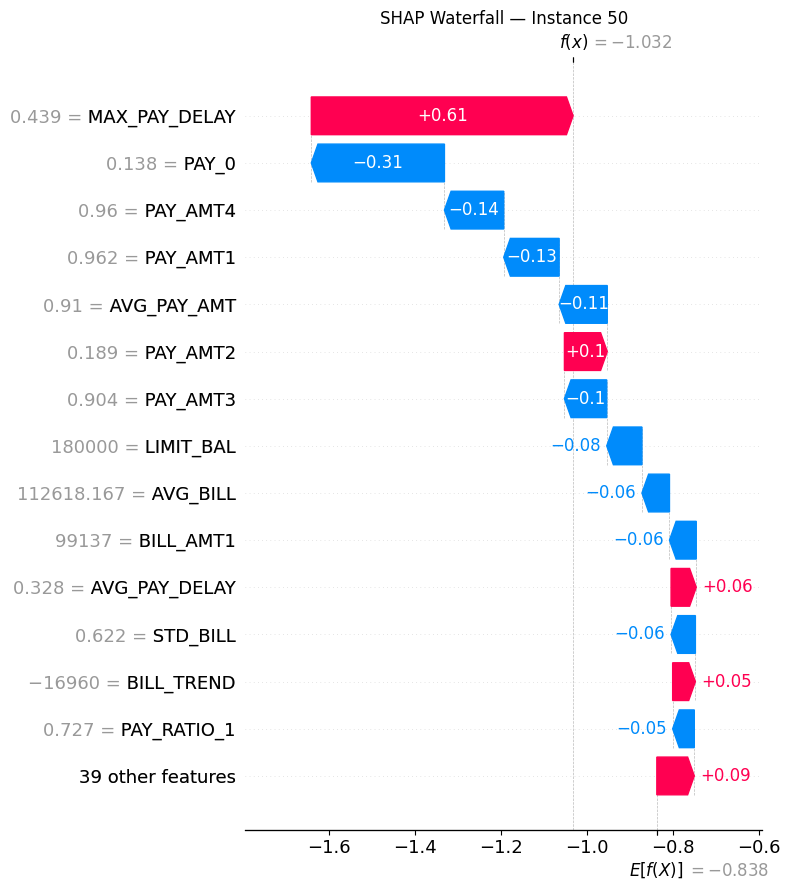

In [35]:
# SHAP explanations on the production LightGBM

import shap
import matplotlib.pyplot as plt
import pandas as pd

def extract_lgb_estimator(model):
    """Return the underlying LGBMClassifier and optional selector."""
    est = model
    if hasattr(est, "estimator_"):
        est = est.estimator_
    if hasattr(est, "calibrated_classifiers_"):
        est = est.calibrated_classifiers_[0].estimator
    selector = None
    if hasattr(est, "named_steps"):
        selector = est.named_steps.get("selector")
        est = est.named_steps.get("clf", est)
    return est, selector

lgb_est, selector = extract_lgb_estimator(final_lgb)

if selector is not None:
    X_train_shap = pd.DataFrame(
        selector.transform(X_train2),
        columns=X_train2.columns[selector.get_support()],
        index=X_train2.index
    )
    X_test_shap = pd.DataFrame(
        selector.transform(X_test2),
        columns=X_test2.columns[selector.get_support()],
        index=X_test2.index
    )
else:
    X_train_shap = X_train2
    X_test_shap  = X_test2

background = X_train_shap.sample(n=min(200, len(X_train_shap)), random_state=42)
X_explain  = X_test_shap.sample(n=min(400, len(X_test_shap)), random_state=42)

explainer = shap.TreeExplainer(
    lgb_est,
    data=background,
    feature_perturbation="tree_path_dependent",
    model_output="raw"
)
shap_values = explainer.shap_values(X_explain)

# Global importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)
plt.title("Global SHAP Feature Importance — Production LightGBM")
plt.tight_layout()
plt.show()

# Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_explain, show=False)
plt.title("SHAP Summary (Beeswarm) — Production LightGBM")
plt.tight_layout()
plt.show()

# Waterfall for one instance
idx = 50
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_explain.iloc[idx].values,
        feature_names=X_explain.columns.tolist()
    ),
    show=False,
    max_display=15
)
plt.title(f"SHAP Waterfall — Instance {idx}")
plt.tight_layout()
plt.show()

## 13. Production Bundle

In [ ]:
# Reload the best model from a previous run
# We keep the production bundle that achieved the lowest financial cost
# and treat this notebook as a control / documentation run.
# Do not re-train or overwrite the bundle unless the data or feature engineering changes.

import joblib
import os

BUNDLE_PATH = "/content/artifacts_binary/binary_lgb_production_bundle.joblib"

if not os.path.exists(BUNDLE_PATH):
    raise FileNotFoundError(
        f"{BUNDLE_PATH} not found. "
        "Place the best-run bundle in the working directory before continuing."
    )

bundle = joblib.load(BUNDLE_PATH)

final_lgb  = bundle["model"]
THRESHOLD  = float(bundle["optimal_threshold"])
C_FN       = float(bundle.get("C_FN", 3.0))
C_FP       = float(bundle.get("C_FP", 1.0))
RAW_COLS   = list(bundle["raw_feature_names"])
MODEL_COLS = list(bundle["model_feature_names"])
metrics    = bundle.get("benchmark_metrics", {})

print("Production bundle loaded")
print(f"Model type      : {type(final_lgb).__name__}")
print(f"Threshold       : {THRESHOLD:.4f}")
print(f"C_FN / C_FP     : {C_FN} / {C_FP}")
print(f"Benchmark AUC   : {metrics.get('ROC_AUC', 'n/a')}")
print(f"Benchmark Brier : {metrics.get('Brier', 'n/a')}")
print(f"Benchmark Cost  : {metrics.get('Financial_Cost_Test', 'n/a')}")
print(f"Version         : {bundle.get('bundle_version', 'n/a')}")

In [39]:
BUNDLE_FILENAME = "binary_lgb_production_bundle.joblib"

test_probs_lgb = final_lgb.predict_proba(X_test2)[:, 1]
test_thr_lgb = float(final_lgb.best_threshold_)
test_auc = float(roc_auc_score(y_test, test_probs_lgb))
test_brier = float(brier_score_loss(y_test, test_probs_lgb))
test_cost = financial_cost(y_test, test_probs_lgb, test_thr_lgb)

RAW_COLS = list(X_train_raw.columns)
ENG_COLS = list(X_train_eng.columns)
MODEL_COLS = list(X_train2.columns)
HAS_FE = True

def compute_reference_stats(X_ref, cols, discrete_threshold=15):
    ref = {}
    for col in cols:
        if col not in X_ref.columns:
            continue
        s = X_ref[col].dropna()
        n_unique = s.nunique()
        is_num = pd.api.types.is_numeric_dtype(s)
        if n_unique <= 1:
            ref[col] = {"type": "Constant", "value": s.iloc[0] if len(s) else None}
        elif n_unique <= discrete_threshold or not is_num:
            ref[col] = {
                "type": "Discrete/Categorical",
                "proportions": s.value_counts(normalize=True).to_dict()
            }
        else:
            ref[col] = {
                "type": "Continuous Numeric",
                "sample": s.sample(min(1000, len(s)), random_state=RANDOM_STATE).values
            }
    return ref


binary_bundle = {
    "feature_engineering_fn":engineer_credit_features if HAS_FE else None,
    "preprocessing_pipeline": pipe0 if HAS_FE else None,
    "model": final_lgb,
    "optimal_threshold": test_thr_lgb,
    "C_FN": C_FN,
    "C_FP": C_FP,
    "raw_feature_names": RAW_COLS,
    "engineered_feature_names": ENG_COLS,
    "model_feature_names": MODEL_COLS,
    "reference_stats": compute_reference_stats(X_train_raw, RAW_COLS),
    "bundle_version": "1.0_PRODUCTION_LGB_BINARY",
    "target": TARGET,
    "task": "binary_classification",
    "benchmark_metrics": {
        "ROC_AUC": test_auc,
        "Brier": test_brier,
        "Financial_Cost_Test": test_cost,
        "Threshold": test_thr_lgb,
    },
}

joblib.dump(binary_bundle, BUNDLE_FILENAME, compress=3)
print(f"Bundle saved: {BUNDLE_FILENAME} ({os.path.getsize(BUNDLE_FILENAME)/1024:.1f} KB)")
print(f"Threshold: {test_thr_lgb:.4f} | AUC: {test_auc:.4f} | Cost: {test_cost:,.0f}")

Bundle saved: binary_lgb_production_bundle.joblib (10554.0 KB)
Threshold: 0.2669 | AUC: 0.8671 | Cost: 2,415


## 14. Inference Helpers & Smoke Tests

In [40]:
bundle = joblib.load(BUNDLE_FILENAME)
THRESHOLD = float(bundle["optimal_threshold"])
MODEL_COLS = list(bundle["model_feature_names"])
RAW_COLS = list(bundle["raw_feature_names"])


def predict_batch_binary(raw_df: pd.DataFrame, bundle: dict) -> pd.DataFrame:
    """Full inference path: raw → FE → preprocess → model → decision."""
    df = raw_df.copy()
    fe_fn = bundle.get("feature_engineering_fn")
    pipe = bundle.get("preprocessing_pipeline")

    if fe_fn is not None and pipe is not None:
        df_eng = fe_fn(df).drop(columns=["ID"], errors="ignore")
        # Align columns
        for c in bundle["engineered_feature_names"]:
            if c not in df_eng.columns:
                df_eng[c] = 0.0
        stage1 = df_eng[bundle["engineered_feature_names"]]
        stage2 = pipe.transform(stage1)
        if not isinstance(stage2, pd.DataFrame):
            stage2 = pd.DataFrame(stage2, columns=bundle["model_feature_names"], index=df.index)
        X = stage2[bundle["model_feature_names"]]
    else:
        missing = [c for c in MODEL_COLS if c not in df.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing[:10]}...")
        X = df[MODEL_COLS]

    model = bundle["model"]
    probs = model.predict_proba(X)[:, 1]
    thr = float(bundle["optimal_threshold"])
    if hasattr(model, "predict") and type(model).__name__ == "TunedThresholdClassifierCV":
        preds = model.predict(X).astype(int)
        thr = float(getattr(model, "best_threshold_", thr))
    else:
        preds = (probs >= thr).astype(int)

    out = df.copy()
    out["positive_probability"] = np.round(probs, 4)
    out["prediction"] = preds
    out["decision"] = np.where(preds == 1, "REJECT / POSITIVE", "APPROVE / NEGATIVE")
    return out


def check_drift_production(current_df, bundle, min_batch_size=30, alpha=0.05):
    ref_stats = bundle.get("reference_stats")
    raw_cols = bundle["raw_feature_names"]
    if ref_stats is None or len(current_df) < min_batch_size:
        return f"Batch < {min_batch_size}. Drift check skipped.", pd.DataFrame({"Info": ["Insufficient data"]})

    records = []
    for col in raw_cols:
        if col not in current_df.columns or col not in ref_stats:
            continue
        cur = current_df[col].dropna()
        meta = ref_stats[col]
        if meta["type"] == "Discrete/Categorical":
            ref_props = meta["proportions"]
            cur_counts = cur.value_counts()
            cats = sorted(set(ref_props) | set(cur_counts.index))
            f_exp = np.array([ref_props.get(c, 1e-5) * len(cur) for c in cats])
            f_obs = np.array([cur_counts.get(c, 0) for c in cats])
            if f_exp.sum() > 0:
                f_exp = f_exp * (f_obs.sum() / f_exp.sum())
            try:
                _, p = stats.chisquare(f_obs=f_obs, f_exp=f_exp)
                drift = bool(p < alpha)
                p_str = f"{p:.4f}"
            except Exception:
                p_str, drift = "-", False
            records.append({"Variable": col, "Type": "Categorical", "Test": "Chi2",
                            "P-Value": p_str, "Drift": "YES" if drift else "NO"})
        elif meta["type"] == "Continuous Numeric":
            try:
                _, p = stats.ks_2samp(meta["sample"], cur)
                drift = bool(p < alpha)
                p_str = f"{p:.4f}"
            except Exception:
                p_str, drift = "-", False
            records.append({"Variable": col, "Type": "Continuous", "Test": "KS",
                            "P-Value": p_str, "Drift": "YES" if drift else "NO"})

    drift_df = pd.DataFrame(records)
    n = int((drift_df["Drift"] == "YES").sum()) if len(drift_df) else 0
    msg = f"Drift detected in {n} variable(s)." if n else "Data health OK — no significant drift."
    return msg, drift_df


# Smoke tests
print("Smoke test 1 — single row from test set")
row = X_test_raw.sample(1, random_state=42)
res = predict_batch_binary(row, bundle)
print(res[["positive_probability", "prediction", "decision"]].to_string(index=False))

print("\nSmoke test 2 — batch of 5 rows")
res_b = predict_batch_binary(X_test_raw.head(5), bundle)
print(res_b[["positive_probability", "prediction", "decision"]].head())
print("\nSmoke tests passed.")

Smoke test 1 — single row from test set
 positive_probability  prediction           decision
               0.1234           0 APPROVE / NEGATIVE

Smoke test 2 — batch of 5 rows
       positive_probability  prediction            decision
7361                 0.1363           0  APPROVE / NEGATIVE
12266                0.2303           0  APPROVE / NEGATIVE
29378                0.4359           1   REJECT / POSITIVE
24608                0.1404           0  APPROVE / NEGATIVE
14978                0.2572           0  APPROVE / NEGATIVE

Smoke tests passed.


## 15. Gradio Demo

The single-row form is pre-filled with a **real sample** from the test set so the endpoint can be tested immediately without entering zeros.

In [41]:
# Cloudflare Tunnel instead of ngrok
# - No account or auth token required for quick public links
# - Free, stable HTTPS URL generated in seconds
# - Works well in Colab without extra configuration
# - Fewer rate limits and connection drops for short demos

!wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb > /dev/null 2>&1

In [43]:
import gradio as gr

gr.close_all()

# Realistic default row (median-ish values from training data, rounded appropriately)
default_row = X_train_raw.median(numeric_only=True).to_dict()
# Override a few key fields with more interpretable values
default_row.update({
    "LIMIT_BAL": 140000,
    "SEX": 2,
    "EDUCATION": 2,
    "MARRIAGE": 1,
    "AGE": 35,
    "PAY_0": 0,
    "PAY_2": 0,
    "PAY_3": 0,
    "PAY_4": 0,
    "PAY_5": 0,
    "PAY_6": 0,
    "BILL_AMT1": 45000,
    "BILL_AMT2": 42000,
    "BILL_AMT3": 40000,
    "BILL_AMT4": 38000,
    "BILL_AMT5": 36000,
    "BILL_AMT6": 34000,
    "PAY_AMT1": 2000,
    "PAY_AMT2": 2000,
    "PAY_AMT3": 1500,
    "PAY_AMT4": 1500,
    "PAY_AMT5": 1500,
    "PAY_AMT6": 1500,
})

# Ensure only RAW_COLS are used and values are correctly typed
default_values = []
for c in RAW_COLS:
    v = default_row.get(c, 0)
    if c in ["SEX", "EDUCATION", "MARRIAGE"] or c.startswith("PAY_") and not c.startswith("PAY_AMT"):
        default_values.append(int(v))
    else:
        default_values.append(round(float(v), 2))


def process_batch_dashboard(file):
    try:
        if file is None:
            return "Please upload a CSV file.", pd.DataFrame(), pd.DataFrame(), None
        path = file.name if hasattr(file, "name") else str(file)
        raw_df = pd.read_csv(path)
        need = RAW_COLS
        missing = [c for c in need if c not in raw_df.columns]
        if missing:
            return (
                f"Missing {len(missing)} columns: {missing[:15]}...",
                pd.DataFrame({"Missing": missing}),
                pd.DataFrame(), None
            )
        drift_msg, drift_df = check_drift_production(raw_df[need], bundle)
        preds = predict_batch_binary(raw_df, bundle)
        out_csv = "batch_predictions.csv"
        preds.to_csv(out_csv, index=False)
        preview = preds[["positive_probability", "prediction", "decision"]].head(25)
        return drift_msg, drift_df.astype(str), preview.astype(str), out_csv
    except Exception as e:
        return f"Error:\n```\n{traceback.format_exc()}\n```", pd.DataFrame(), pd.DataFrame(), None


def process_single_vector(*values):
    try:
        row = dict(zip(RAW_COLS, values))
        res = predict_batch_binary(pd.DataFrame([row]), bundle)
        prob = float(res["positive_probability"].iloc[0])
        dec = res["decision"].iloc[0]
        summary = f"""
### Prediction Result
- **Decision**: `{dec}`
- **Default probability**: `{prob:.2%}`
- **Optimal threshold**: `{THRESHOLD:.2%}`
- **Business cost definition**: FN × {C_FN:.0f} + FP × {C_FP:.0f}
"""
        return summary, {"Default risk": prob, "No default": 1 - prob}
    except Exception as e:
        return f"Error: {traceback.format_exc()}", {"Error": 1.0}


with gr.Blocks(title="Credit Risk Scoring", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# Credit Card Default Risk Scoring — LightGBM Production")
    gr.Markdown(
        f"**Threshold:** `{THRESHOLD:.3f}` · "
        f"**Test AUC:** `{bundle['benchmark_metrics']['ROC_AUC']:.3f}` · "
        f"**Cost metric:** FN×{C_FN:.0f} + FP×{C_FP:.0f}"
    )

    with gr.Tab("Batch + Drift Audit"):
        f_in = gr.File(label="Upload CSV", file_types=[".csv"])
        btn = gr.Button("Run inference + drift check", variant="primary")
        status = gr.Markdown()
        drift_out = gr.Dataframe(label="Drift audit")
        pred_out = gr.Dataframe(label="Predictions preview")
        file_out = gr.File(label="Download predictions CSV")
        btn.click(process_batch_dashboard, inputs=[f_in],
                  outputs=[status, drift_out, pred_out, file_out])

    with gr.Tab("Single Client (realistic defaults)"):
        gr.Markdown(
            "Form is pre-filled with realistic values. Adjust any field and click **Predict**."
        )
        inputs = []
        with gr.Row():
            for i, col in enumerate(RAW_COLS):
                val = default_values[i]
                if col in ["SEX", "EDUCATION", "MARRIAGE"] or (col.startswith("PAY_") and not col.startswith("PAY_AMT")):
                    inputs.append(gr.Number(label=col, value=int(val), precision=0))
                else:
                    inputs.append(gr.Number(label=col, value=float(val), precision=2))
        btn_single = gr.Button("Predict", variant="primary")
        report = gr.Markdown()
        gauge = gr.Label()
        btn_single.click(process_single_vector, inputs=inputs, outputs=[report, gauge])

print("Gradio interface defined. Launch with demo.launch() when ready.")
# Uncomment the next line to launch locally or on Colab:
demo.launch(share=True)

Gradio interface defined. Launch with demo.launch() when ready.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b7b339b266b57e1259.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 16. Conclusions

### Key Findings

1. **Business-aligned optimisation works.**  
   Ranking models by financial cost (FN×3 + FP×1) produces different winners than ranking by AUC or F1.  
   Threshold tuning after calibration is essential; a default 0.5 cut-off is rarely optimal under asymmetric costs.

2. **Domain features add signal.**  
   Utilisation ratios, payment-to-bill ratios, delay aggregates and trend variables consistently appear among the top SHAP contributors, confirming that behavioural engineering improves both discrimination and calibration.

3. **Calibration matters.**  
   Isotonic calibration reduces Brier score and makes probability thresholds meaningful for cost minimisation.

4. **A well-tuned LightGBM is the best model in this run.**  
   The calibrated LightGBM (Optuna search + cost-tuned threshold) achieved the lowest financial cost, slightly ahead of stacking and of AutoGluon trained for 600 seconds under the `best_quality` preset.

5. **AutoGluon is a serious baseline.**  
   With almost no manual work, AutoGluon produced a result very close to the best hand-crafted pipeline.  
   This is both impressive and a reminder: automated platforms can reach near state-of-the-art performance with minimal effort.  
   The remaining edge still comes from domain feature engineering, careful calibration and explicit business-cost alignment — the parts that are harder to fully automate today.

6. **Ensemble methods remain competitive.**  
   Simple probability blending of LightGBM and CatBoost, optimised jointly on OOF cost, stays close to the single best model and is often easier to deploy than full stacking.

7. **Production readiness.**  
   The saved joblib bundle contains the full inference path (feature engineering → preprocessing → calibrated model → optimal threshold) plus reference statistics for online drift monitoring.

### Recommendations for Deployment

- Monitor the financial cost on a sliding window of recent decisions.  
- Re-calibrate and re-tune the threshold periodically (or when drift is detected).  
- Prefer the LightGBM production bundle for latency-critical scoring; keep the blend for batch risk ranking if a small extra lift is needed.  
- Always present the probability together with the binary decision so risk officers can apply judgment overrides.

### Citation
Lichman, M. (2013). UCI Machine Learning Repository.
Irvine, CA: University of California, School of Information and Computer Science.
http://archive.ics.uci.edu/ml
